# Individuele opdracht Data Science — CRISP-DM
## Treinverstoringen voorspellen

> Deze opdracht is met behulp van een Large Language Model (LLM) aangepast, zodat de inhoud en het niveau optimaal aansluiten bij de verwachte kennis en vaardigheden van een tweedejaars ICT-student (BIM).

**Naam student:** Ayoub Lahiani  
**Studentnummer:** 1884794  

In deze individuele opdracht doorloop je de fasen van **CRISP-DM**. Je onderzoekt Nederlandse treinverstoringen en bouwt een model dat bij de start van een verstoring voorspelt of deze langer dan 60 minuten zal duren.

De nadruk ligt op het begrijpen van de data, aantoonbare datamanipulatie, een eerlijke modelvergelijking en een onderbouwde evaluatie. De fase **Deployment** valt buiten deze opdracht.

> Dit notebook volgt de eisen uit `Opdracht_CRISP-DM_treinverstoringen.docx`. Startcode laat een techniek en de reden erachter zien. Je moet de controles uitbreiden, keuzes onderbouwen en uitkomsten zelf interpreteren. Alleen de voorbeeldcode uitvoeren is niet voldoende.


## Overzicht en weging

| CRISP-DM-fase | Wat je aantoont | Weging |
|---|---|---:|
| 1. Business Understanding | Je begrijpt het doel van de voorspelling | 5% |
| 2. Data Understanding | Je begrijpt inhoud, typen, verdelingen en kwaliteit van de data | 20% |
| 3. Data Preparation | Je maakt de data met beargumenteerde manipulaties modelklaar | 30% |
| 4. Modeling | Je bouwt en vergelijkt een baseline en minimaal twee modellen | 20% |
| 5. Evaluation | Je test het gekozen model en vertaalt resultaten naar de businessvraag | 25% |

### Verplichte inleverproducten

Lever samen in:

1. dit volledig ingevulde en uitgevoerde notebook;
2. de voorbereide modeldataset vóór one-hot encoding als CSV;
3. een korte `README.md` of `README.txt` met startinstructie, Python-versie, packages en bestandsnamen.

Een HTML- of PDF-export mag als extra leesversie worden toegevoegd, maar vervangt het notebook niet. Het notebook moet van boven naar beneden opnieuw uitvoerbaar zijn. Gebruik overal `random_state=42` waar dat van toepassing is.


## Werkwijze en beoordelingsafspraken

- Schrijf bij iedere analyse op **wat je ziet**, **waarom dat belangrijk is** en **welke keuze daaruit volgt**.
- Leg beslissingen vast vóórdat je verdergaat. Voorbeelden zijn verwijderen, imputeren, categorieën samenvoegen en omgaan met uitschieters.
- Voorkom **data leakage**. Informatie die pas tijdens of na afloop van een verstoring beschikbaar is, mag niet als invoer van het model worden gebruikt.
- Laat datavoorbereiding die van waarden of frequenties leert uitsluitend op de trainingsdata plaatsvinden. Gebruik hiervoor bij voorkeur een scikit-learn `Pipeline` en `ColumnTransformer`.
- Vermeld geraadpleegde bronnen en eventuele AI-ondersteuning volgens de afspraken van de opleiding.

### Betekenis van labels

- `OPDRACHT`: dit moet je aantoonbaar opleveren.
- `TODO`: dit moet je aanvullen, activeren of aanpassen.
- `CONTROLEPUNT`: hiermee controleer je of je voldoende bewijs hebt geleverd.
- `VOORBEELD`: startcode die één techniek demonstreert. Controleer of de aanpak past bij jouw bevindingen.

Commentaar in de voorbeeldcode legt uit waarom een stap wordt uitgevoerd. Verwijder relevante uitleg niet zonder reden. Voeg eigen commentaar toe wanneer je een andere keuze maakt.


# 0. Voorbereiding

Plaats de dataset in dezelfde map als het notebook. De verwachte bestandsnaam is `Dataset.csv`. Het template herkent ook `Dataset(1).csv`, omdat een browser soms automatisch `(1)` toevoegt. De velden zijn met een puntkomma (`;`) gescheiden.

Voer eerst de importcel uit. De controle op 14 kolommen voorkomt dat een verkeerd scheidingsteken ongemerkt één brede tekstkolom oplevert. Voeg alleen bibliotheken toe die je daadwerkelijk gebruikt.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="colorblind")

# Relatieve paden blijven werken wanneer iemand de map verplaatst.
# De varianten met (1) vangen automatisch hernoemde downloads op.
candidate_paths = [
    Path("Dataset.csv"),
    Path("Dataset(1).csv"),
    Path("upload") / "Dataset.csv",
    Path("upload") / "Dataset(1).csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    df_raw = None
    print("Dataset.csv is niet gevonden. Plaats het bestand naast het notebook en voer deze cel opnieuw uit.")
else:
    # sep=';' is nodig omdat komma's ook binnen meervoudige tekstvelden voorkomen.
    df_raw = pd.read_csv(DATA_PATH, sep=";")
    print(f"Data ingelezen uit: {DATA_PATH}")
    print(f"Omvang: {df_raw.shape[0]} rijen en {df_raw.shape[1]} kolommen")
    assert df_raw.shape[1] == 14, "Controleer het scheidingsteken; er worden 14 kolommen verwacht."


Data ingelezen uit: Dataset.csv
Omvang: 6676 rijen en 14 kolommen


# 1. Business Understanding — 5%

## Businessvraag

> **Kan op het moment dat een treinverstoring begint worden voorspeld of deze langer dan 60 minuten zal duren, op basis van de oorzaak, het getroffen traject, het aantal getroffen stations en het startmoment?**

Het gaat om een classificatieprobleem met twee klassen:

- `0`: de verstoring duurt maximaal 60 minuten;
- `1`: de verstoring duurt langer dan 60 minuten.

## Opdracht 1.1 — Korte duiding

Neem de businessvraag letterlijk over en licht in twee tot vier zinnen toe wie de voorspelling kan gebruiken en welke beslissing ermee wordt ondersteund. Benoem ook welk type fout volgens jou het zwaarst weegt. Deze keuze gebruik je later om de primaire evaluatiemaat te kiezen.

**Jouw antwoord:**
Kan op het moment dat een treinverstoring begint worden voorspeld of deze langer dan 60 minuten zal duren, op basis van de oorzaak, het getroffen traject, het aantal getroffen stations en het startmoment?

De voorspelling kan gebruikt worden door bijvoorbeeld NS zelf die treinverstoringen monitort om bij het begin van een verstoring snel in te schatten of deze langer dan 60 minuten zal duren met die informatie kan wat sneller worden bepaald hoe reizigers geïnformeerd moeten worden en of maatregelen nodig moeten zijn. Ik vind het zwaarder wegen om een langere verstoring te voorspellen als een korte, omdat reizigers dan mogelijk te laat worden geïnformeerd en zij misschien een andere mogelijkheid proberen te zoeken om te reizen terwijl de verstoring tijdelijk zou zijn.
### Controlepunt

De zakelijke betekenis en het voorspelmoment zijn duidelijk. Een uitgebreide organisatieanalyse is niet nodig; de nadruk ligt op de volgende fasen.


# 2. Data Understanding — 20%

In deze fase leg je de oorspronkelijke toestand van de data vast. Reinig nog niets. Baseer je analyse ook op **Beschrijving van de data.docx**.

## Opdracht 2.1 — Inlezen en eerste controle

Onderzoek minimaal:

1. het gebruikte scheidingsteken en of alle 14 kolommen afzonderlijk zijn ingelezen;
2. het aantal rijen, kolommen en unieke verstorings-ID's;
3. de eerste vijf, laatste vijf en minimaal vijf willekeurige records;
4. de kolomnamen en door pandas herkende datatypen;
5. de vroegste en laatste bruikbare startdatum;
6. of `rdt_id` daadwerkelijk een unieke sleutel lijkt te zijn.

Gebruik de startcode en voeg eigen controles toe. Een tabel zonder interpretatie is niet voldoende.


In [2]:
if df_raw is not None:
    print("Vorm:", df_raw.shape)
    display(df_raw.head())
    display(df_raw.tail())

    # random_state maakt dezelfde steekproef opnieuw reproduceerbaar.
    display(df_raw.sample(5, random_state=RANDOM_STATE))
    display(df_raw.dtypes.rename("pandas_dtype").to_frame())

    # errors='coerce' maakt ongeldige teksten NaT. Zo kun je mislukte
    # conversies tellen zonder de ruwe kolom te overschrijven.
    start_time_check = pd.to_datetime(
        df_raw["start_time"], errors="coerce", dayfirst=True
    )
    print("Vroegste bruikbare start:", start_time_check.min())
    print("Laatste bruikbare start:", start_time_check.max())

    print("Aantal unieke rdt_id's:", df_raw["rdt_id"].nunique(dropna=False))
    print("Aantal dubbele rdt_id's:", df_raw["rdt_id"].duplicated().sum())
    print("Lege starttijden:", start_time_check.isna().sum())



    


Vorm: (6676, 14)


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,57284,Den Haag - Rotterdam - Dordrecht,Den Haag HS - Rotterdam Centraal,11,"Delft,Delft Campus,Schiedam Centrum","DT, DTCP, SDM",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:16,1-1-2025 04:26,10.0
1,57285,Leiden - Rotterdam,Den Haag HS - Rotterdam Centraal,11,"Delft,Delft Campus,Schiedam Centrum","DT, DTCP, SDM",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:27,1-1-2025 06:23,117.0
2,57286,Rotterdam - Dordrecht,Dordrecht - Rotterdam Centraal,16,"Barendrecht,Dordrecht,Rotterdam Lombardijen,Ro...","BRD, DDR, RLB, RTB, RTD, RTST, RTZ, ZWD",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:27,1-1-2025 04:29,3.0
3,57287,Schiphol - Rotterdam,Rotterdam Centraal - Schiphol Airport (HSL),24,"Rotterdam Centraal,Schiphol Airport","RTD, SHL",verstoring elders,disruption elsewhere,verstoring elders,disruption elsewhere,logistical,1-1-2025 04:27,1-1-2025 04:27,0.0
4,57288,Schiphol - Rotterdam,Rotterdam Centraal - Schiphol Airport (HSL),24,"Rotterdam Centraal,Schiphol Airport","RTD, SHL",verstoring elders,disruption elsewhere,verstoring elders,disruption elsewhere,logistical,1-1-2025 04:27,1-1-2025 06:40,133.0


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
6671,63955,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Mariënberg,Vroomshoop,Vriez...","AML, DA, MRB, VHP, VZ",vandalisme,vandalism,vandalisme,vandalism,external,31-12-2025 15:14,31-12-2025 15:48,34.0
6672,63956,Schiphol Airport,"Amersfoort - Schiphol Airport, Amsterdam Centr...","22,24,32,137,144,148,165","Rosmalen,Schiphol Airport","RS, SHL",brandmelding,fire alarm,brandmelding,fire alarm,external,31-12-2025 16:19,31-12-2025 17:00,41.0
6673,63957,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Mariënberg,Vroomshoop,Vriez...","AML, DA, MRB, VHP, VZ",vandalisme,vandalism,vandalisme,vandalism,external,31-12-2025 16:31,31-12-2025 21:15,284.0
6674,63958,Hilversum - Amersfoort Schothorst,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst","AMF, AMFS",defecte trein,broken down train,defecte trein,broken down train,rolling stock,31-12-2025 18:48,31-12-2025 19:40,51.0
6675,63959,Alkmaar,"Alkmaar - Amsterdam Centraal, Alkmaar - Den He...","161,162,163","Alkmaar,Oisterwijk,Dülken","AMR, OT, KDUL",aanrijding,collision,aanrijding,collision,accidents,31-12-2025 19:41,31-12-2025 19:46,6.0


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
1575,58859,Utrecht - Nijmegen,Arnhem Centraal - Utrecht Centraal,133,"Arnhem Centraal,Ede-Wageningen,Oosterbeek,Wolf...","AH, ED, OTB, WF",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,18-3-2025 17:13,18-3-2025 17:23,10.0
6445,63729,'s-Hertogenbosch - Tilburg,'s-Hertogenbosch - Tilburg,69,"'s-Hertogenbosch,Tilburg","HT, TB",gestrande trein,stranded train,gestrande trein,stranded train,rolling stock,16-12-2025 07:50,16-12-2025 08:31,41.0
4622,61906,Hengelo - Bielefeld,Bielefeld Hbf - Hengelo,174,"Osnabrück Hbf,Bielefeld Hbf,Bünde (Westf)","OSNH, BIELEF, BUENDE",problemen op het spoor in het buitenland,railway problems abroad,problemen op het spoor in het buitenland,railway problems abroad,logistical,9-9-2025 09:33,9-9-2025 21:45,733.0
2107,59391,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Hardenberg,Mariënberg,Vroom...","AML, DA, HDB, MRB, VHP, VZ",beperkingen in de materieelinzet,problems with the rolling stock,beperkingen in de materieelinzet,problems with the rolling stock,rolling stock,17-4-2025 06:24,17-4-2025 09:01,157.0
1360,58644,Hilversum - Amersfoort Schothorst,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst","AMF, AMFS",wisselstoring,points failure,wisselstoring,points failure,infrastructure,6-3-2025 19:11,6-3-2025 22:18,186.0


,pandas_dtype
rdt_id,int64
ns_lines,str
rdt_lines,str
rdt_lines_id,str
rdt_station_names,str
rdt_station_codes,str
cause_nl,str
cause_en,str
statistical_cause_nl,str
statistical_cause_en,str


Vroegste bruikbare start: 2025-01-01 04:16:00
Laatste bruikbare start: 2025-12-31 19:41:00
Aantal unieke rdt_id's: 6676
Aantal dubbele rdt_id's: 0
Lege starttijden: 939


### Bevindingen eerste inspectie

Beschrijf hier drie tot vijf relevante bevindingen. Vermeld niet alleen aantallen, maar leg uit wat ze betekenen voor de rest van je analyse.

**Jouw bevindingen:**

Vorm: (6676, 14) 
Vroegste bruikbare start: 2025-01-01 04:16:00 
Laatste bruikbare start: 2025-12-31 19:41:00 
Aantal unieke rdt_id's: 6676 
Aantal dubbele rdt_id's: 0
Aantal lege kolommen: 939

De dataset bestaat uit 6.676 rijen en 14 kolommen. `rdt_id` is voor elke rij uniek. Dus elke rij is 1 storing. Een belangrijk probleem met de kwaliteit van de data is dat in meerdere kolommen tegelijk waarden ontbreken er staan gewoon veel dingen simpelweg niet in. Vooral bij de tijd- en oorzaakvelden ontbreken gegevens bij een groep records. Sommige kolommen bevatten meerdere waarden in 1 cel, bijvoorbeeld meerdere stations of trajecten.



## Opdracht 2.2 — Datatypen, meetniveaus en rollen

Maak voor **alle 14 variabelen** een datawoordenboek met minimaal:

- betekenis van het veld;
- huidig technisch datatype;
- gewenst datatype;
- meetniveau: nominaal, ordinaal, interval of ratio;
- inhoudelijke vorm, zoals identifier, datum/tijd, categorie of multi-value tekstveld;
- mogelijke rol: invoerkenmerk, doelbron, controleveld of niet gebruiken;
- korte toelichting.

Een numerieke code is niet automatisch een kwantitatieve variabele. `rdt_id` is bijvoorbeeld numeriek opgeslagen, maar heeft inhoudelijk de rol van nominale identifier.


In [3]:
if df_raw is not None:
    # Start met één rij per bronkolom. Vul de inhoud vervolgens bewust per kolom in.
    data_dictionary = pd.DataFrame(index=df_raw.columns).reset_index(names="kolom")
    data_dictionary["huidig_dtype"] = [str(dtype) for dtype in df_raw.dtypes]
    data_dictionary["betekenis"] = [
        "Uniek verstorings-ID",
        "Getroffen trajecten uit NS-bericht",
        "Gestandaardiseerde getroffen trajecten",
        "ID's van getroffen trajecten",
        "Namen van getroffen stations",
        "Codes van getroffen stations",
        "Laatst getoonde oorzaak in het Nederlands",
        "Vertaling van de oorzaak in het Engels",
        "Statistische oorzaak in het Nederlands",
        "Vertaling van de statistische oorzaak in het Engels",
        "Groep van de storingsoorzaak",
        "Moment waarop de verstoring begon",
        "Moment waarop de verstoring eindigde",
        "Duur van de verstoring in minuten",
    ]
    data_dictionary["gewenst_dtype"] = [
        "Int64", "string", "string", "string", "string", "string",
        "string", "string", "string", "string", "string",
        "datetime64[ns]", "datetime64[ns]", "float64"
    ]
    data_dictionary["meetniveau"] = [
        "nominaal", "nominaal", "nominaal", "nominaal", "nominaal", "nominaal",
        "nominaal", "nominaal", "nominaal", "nominaal", "nominaal",
        "interval", "interval", "ratio"
    ]
    data_dictionary["inhoudelijke_vorm"] = [
        "identifier", "multi-value tekst", "multi-value tekst", "multi-value identifier",
        "multi-value tekst", "multi-value identifier", "categorie", "categorie",
        "categorie", "categorie", "categorie", "datum/tijd", "datum/tijd", "numerieke waarde"
    ]
    data_dictionary["mogelijke_rol"] = [
        "niet gebruiken", "niet gebruiken", "bron voor kenmerk", "controle",
        "bron voor kenmerk", "controle", "niet gebruiken", "niet gebruiken",
        "invoerkenmerk", "niet gebruiken", "invoerkenmerk", "bron voor kenmerken",
        "niet gebruiken", "bron voor target"
    ]
    data_dictionary["toelichting"] = [
        "Alleen voor herkenning en controle van unieke verstoringen.",
        "Niet gestandaardiseerd en daarom minder geschikt voor het model.",
        "Kan worden gebruikt om het aantal getroffen trajecten te bepalen.",
        "Kan worden gebruikt om het aantal trajecten te controleren.",
        "Kan worden gebruikt om het aantal getroffen stations te bepalen.",
        "Kan worden gebruikt om stationsnamen te controleren.",
        "De oorzaak kan tijdens een verstoring veranderen.",
        "Bevat dezelfde informatie als cause_nl, maar dan in het Engels.",
        "Kan informatie geven over de oorzaak, maar kan ook later zijn vastgelegd.",
        "Bevat dezelfde informatie als statistical_cause_nl, maar dan in het Engels.",
        "Een grovere oorzaakgroep en daarom geschikt als voorspeller.",
        "Wordt gebruikt om kenmerken zoals uur, maand en weekdag te maken.",
        "Is pas na afloop bekend en mag niet als invoer worden gebruikt.",
        "Wordt gebruikt om long_disruption te bepalen en mag niet als invoer worden gebruikt.",
    ]
    display(data_dictionary)


,kolom,huidig_dtype,betekenis,gewenst_dtype,meetniveau,inhoudelijke_vorm,mogelijke_rol,toelichting
0,rdt_id,int64,Uniek verstorings-ID,Int64,nominaal,identifier,niet gebruiken,Alleen voor herkenning en controle van unieke ...
1,ns_lines,str,Getroffen trajecten uit NS-bericht,string,nominaal,multi-value tekst,niet gebruiken,Niet gestandaardiseerd en daarom minder geschi...
2,rdt_lines,str,Gestandaardiseerde getroffen trajecten,string,nominaal,multi-value tekst,bron voor kenmerk,Kan worden gebruikt om het aantal getroffen tr...
3,rdt_lines_id,str,ID's van getroffen trajecten,string,nominaal,multi-value identifier,controle,Kan worden gebruikt om het aantal trajecten te...
4,rdt_station_names,str,Namen van getroffen stations,string,nominaal,multi-value tekst,bron voor kenmerk,Kan worden gebruikt om het aantal getroffen st...
5,rdt_station_codes,str,Codes van getroffen stations,string,nominaal,multi-value identifier,controle,Kan worden gebruikt om stationsnamen te contro...
6,cause_nl,str,Laatst getoonde oorzaak in het Nederlands,string,nominaal,categorie,niet gebruiken,De oorzaak kan tijdens een verstoring veranderen.
7,cause_en,str,Vertaling van de oorzaak in het Engels,string,nominaal,categorie,niet gebruiken,"Bevat dezelfde informatie als cause_nl, maar d..."
8,statistical_cause_nl,str,Statistische oorzaak in het Nederlands,string,nominaal,categorie,invoerkenmerk,"Kan informatie geven over de oorzaak, maar kan..."
9,statistical_cause_en,str,Vertaling van de statistische oorzaak in het E...,string,nominaal,categorie,niet gebruiken,Bevat dezelfde informatie als statistical_caus...


## Opdracht 2.3 — Datakwaliteit

Onderzoek en bespreek minimaal:

1. ontbrekende waarden per kolom, in aantal én percentage;
2. patronen van gelijktijdig ontbrekende velden;
3. volledig dubbele rijen en dubbele identifiers;
4. ongeldige datums en eindtijden vóór starttijden;
5. negatieve, nul- en uitzonderlijk hoge duren;
6. overeenstemming tussen `duration_minutes` en het verschil tussen start- en eindtijd;
7. overeenstemming tussen aantallen stationsnamen en stationcodes;
8. overeenstemming tussen aantallen trajectnamen en traject-ID's;
9. hoofdletters, witruimte, lege teksten en zeldzame categorieën in minimaal `cause_group`, `statistical_cause_nl` en `rdt_lines`;
10. velden die door het voorspelmoment of hun betekenis ongeschikt zijn als modelinvoer.

Maak bij ieder probleem duidelijk hoe je het hebt ontdekt, hoe groot het is, wat het kan betekenen en wat je er in Data Preparation mee gaat doen.


In [4]:
# VOORBEELD: aantallen en percentages ontbreken per kolom.
if df_raw is not None:
    missing_summary = (
        df_raw.isna()
        .sum()
        .rename("aantal_ontbrekend")
        .to_frame()
        .assign(percentage=lambda x: 100 * x["aantal_ontbrekend"] / len(df_raw))
        .sort_values("percentage", ascending=False)
    )
    display(missing_summary.round(2))

    print("Volledig dubbele rijen:", df_raw.duplicated().sum())
    print("Dubbele rdt_id's:", df_raw["rdt_id"].duplicated().sum())

    # Het aantal ontbrekende velden per rij laat zien of missings los voorkomen
    # of dat veel velden binnen dezelfde records tegelijk ontbreken.
    missing_fields_per_row = df_raw.isna().sum(axis=1)
    display(
        missing_fields_per_row.value_counts().sort_index()
        .rename_axis("aantal_ontbrekende_velden_in_rij")
        .rename("aantal_rijen")
        .to_frame()
    )

    print("Rijen met de meeste ontbrekende velden:")
    max_missing = missing_fields_per_row.max()
    display(df_raw.loc[missing_fields_per_row == max_missing].head(5))
    print(f"Maximaal aantal ontbrekende velden in één rij: {max_missing}")


,aantal_ontbrekend,percentage
rdt_lines,940,14.08
rdt_lines_id,940,14.08
end_time,940,14.08
duration_minutes,940,14.08
rdt_station_names,939,14.07
rdt_station_codes,939,14.07
cause_nl,939,14.07
cause_en,939,14.07
statistical_cause_nl,939,14.07
statistical_cause_en,939,14.07


Volledig dubbele rijen: 0
Dubbele rdt_id's: 0


,aantal_rijen
aantal_ontbrekende_velden_in_rij,
0,5735
2,2
12,939


Rijen met de meeste ontbrekende velden:


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
5,57289,Dordrecht - Breda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,57295,Hilversum - Amersfoort,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,57300,Breda - Eindhoven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,57311,Sittard - Heerlen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,57314,Zwolle - Groningen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Maximaal aantal ontbrekende velden in één rij: 12


In [5]:
# VOORBEELD: datums en duur controleren zonder de ruwe data te overschrijven.
if df_raw is not None:
    understanding = df_raw.copy()
    understanding["start_time_dt"] = pd.to_datetime(
        understanding["start_time"], errors="coerce", dayfirst=True
    )
    understanding["end_time_dt"] = pd.to_datetime(
        understanding["end_time"], errors="coerce", dayfirst=True
    )

    invalid_start = understanding["start_time"].notna() & understanding["start_time_dt"].isna()
    invalid_end = understanding["end_time"].notna() & understanding["end_time_dt"].isna()
    end_before_start = understanding["end_time_dt"] < understanding["start_time_dt"]

    print("Niet-converteerbare starttijden:", invalid_start.sum())
    print("Niet-converteerbare eindtijden:", invalid_end.sum())
    print("Eindtijd vóór starttijd:", end_before_start.sum())

    understanding["calculated_duration_minutes"] = (
        understanding["end_time_dt"] - understanding["start_time_dt"]
    ).dt.total_seconds() / 60
    understanding["duration_difference"] = (
        understanding["duration_minutes"]
        - understanding["calculated_duration_minutes"]
    )

    # Een tolerantie van één minuut kan passen bij afronding op hele minuten.
    # Onderbouw zelf of deze tolerantie bij de gevonden waarden verdedigbaar is.
    TOLERANCE_MINUTES = 1
    duration_mismatch_mask = (
        understanding["duration_difference"].abs() > TOLERANCE_MINUTES
    )
    display(understanding.loc[duration_mismatch_mask, [
        "rdt_id", "start_time", "end_time", "duration_minutes",
        "calculated_duration_minutes", "duration_difference"
    ]].head(10))

    duration_flags = pd.Series({
        "negatief": (understanding["duration_minutes"] < 0).sum(),
        "nul": (understanding["duration_minutes"] == 0).sum(),
        "langer_dan_een_dag": (understanding["duration_minutes"] > 1440).sum(),
        "maximum": understanding["duration_minutes"].max(),
    }, name="waarde")
    display(duration_flags.to_frame())

    print("Rijen met een uitschieter:")
    display(understanding.loc[duration_mismatch_mask, ["rdt_id", "start_time", "end_time", "duration_minutes", "calculated_duration_minutes", "duration_difference"]])
    print("Aantal negatieve duren:", (understanding["duration_minutes"] < 0).sum())
    print("Aantal duren langer dan 1 dag:", (understanding["duration_minutes"] > 1440).sum())


Niet-converteerbare starttijden: 0
Niet-converteerbare eindtijden: 0
Eindtijd vóór starttijd: 0


,rdt_id,start_time,end_time,duration_minutes,calculated_duration_minutes,duration_difference
5483,62767,25-10-2025 00:47,27-10-2025 23:52,4325.0,4265.0,60.0


,waarde
negatief,0.0
nul,63.0
langer_dan_een_dag,66.0
maximum,31351.0


Rijen met een uitschieter:


,rdt_id,start_time,end_time,duration_minutes,calculated_duration_minutes,duration_difference
5483,62767,25-10-2025 00:47,27-10-2025 23:52,4325.0,4265.0,60.0


Aantal negatieve duren: 0
Aantal duren langer dan 1 dag: 66


In [6]:
def count_multivalue_items(value, separator=","):
    '''Tel niet-lege, door een scheidingsteken gescheiden onderdelen.'''
    if pd.isna(value):
        return np.nan
    items = [item.strip() for item in str(value).split(separator)]
    return sum(bool(item) for item in items)


if df_raw is not None:
    station_name_count = df_raw["rdt_station_names"].map(count_multivalue_items)
    station_code_count = df_raw["rdt_station_codes"].map(count_multivalue_items)
    line_name_count = df_raw["rdt_lines"].map(count_multivalue_items)
    line_id_count = df_raw["rdt_lines_id"].map(count_multivalue_items)

    # Vergelijk alleen rijen waarin beide waarden aanwezig zijn. Zonder dit masker
    # kan NaN != NaN ten onrechte als een inhoudelijke afwijking worden geteld.
    comparable_stations = station_name_count.notna() & station_code_count.notna()
    comparable_lines = line_name_count.notna() & line_id_count.notna()
    station_mismatch = comparable_stations & (station_name_count != station_code_count)
    line_mismatch = comparable_lines & (line_name_count != line_id_count)

    print("Vergelijkbare stationsrecords:", comparable_stations.sum())
    print("Afwijkend aantal stationsnamen en -codes:", station_mismatch.sum())
    print("Vergelijkbare trajectrecords:", comparable_lines.sum())
    print("Afwijkend aantal trajectnamen en -ID's:", line_mismatch.sum())

    display(df_raw.loc[station_mismatch, [
        "rdt_id", "rdt_station_names", "rdt_station_codes"
    ]].head(10))
    display(df_raw.loc[line_mismatch, [
        "rdt_id", "rdt_lines", "rdt_lines_id"
    ]].head(10))

# De uitkomsten zijn de vergeleken stationsnamen en stationcodes op rijen waar beide velden aanwezig zijn.
# Zowel als trajectnamen en traject-ID's. De aantallen kan ik later gebruiken voor features.



Vergelijkbare stationsrecords: 5737
Afwijkend aantal stationsnamen en -codes: 0
Vergelijkbare trajectrecords: 5736
Afwijkend aantal trajectnamen en -ID's: 0


,rdt_id,rdt_station_names,rdt_station_codes


,rdt_id,rdt_lines,rdt_lines_id




### Categorische kwaliteit

Onderstaande startcode kwantificeert enkele veelvoorkomende problemen. Een categorie met weinig records is niet automatisch fout. Zeldzaamheid kan wel leiden tot instabiele dummyvariabelen of zeer kleine analysegroepen.


In [7]:
if df_raw is not None:
    category_quality = []
    for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        values = df_raw[column].dropna().astype(str)
        frequencies = values.value_counts()
        category_quality.append({
            "kolom": column,
            "unieke_waarden": values.nunique(),
            "categorieen_minder_dan_5": (frequencies < 5).sum(),
            "voor_of_achterspatie": (values != values.str.strip()).sum(),
            "lege_tekst": values.str.strip().eq("").sum(),
        })
    display(pd.DataFrame(category_quality))

for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        values = df_raw[column].dropna().astype(str).str.strip()
        print(f"Voorbeeldwaarden na strippen voor {column}:")
        display(values.value_counts().head(10).rename("aantal").to_frame())

    # De data bevat zeldzame categorieën; deze worden niet blind samengevoegd.

,kolom,unieke_waarden,categorieen_minder_dan_5,voor_of_achterspatie,lege_tekst
0,cause_group,9,0,0,0
1,statistical_cause_nl,63,18,0,0
2,rdt_lines,217,64,0,0


Voorbeeldwaarden na strippen voor cause_group:


,aantal
cause_group,
rolling stock,2608
infrastructure,1316
external,728
accidents,360
unknown,236
staff,197
logistical,129
engineering work,116
weather,47


Voorbeeldwaarden na strippen voor statistical_cause_nl:


,aantal
statistical_cause_nl,
defecte trein,2118
seinstoring,448
gestrande trein,363
aanrijding,335
wisselstoring,305
technisch onderzoek,234
persoon op het spoor,181
inzet van hulpdiensten,145
beperkingen in de materieelinzet,121


Voorbeeldwaarden na strippen voor rdt_lines:


,aantal
rdt_lines,
Breda - Rotterdam Centraal (HSL),253
Rotterdam Centraal - Schiphol Airport (HSL),150
Amersfoort - Zwolle,127
Leiden Centraal - Schiphol Airport,123
's-Hertogenbosch - Nijmegen,118
Eindhoven - Venlo,107
Aachen Hbf - Heerlen,106
Leiden Centraal - Utrecht Centraal,103
Dordrecht - Rotterdam Centraal,96


### Datakwaliteitsrapport

Sluit Data Understanding af met minimaal vijf concreet gevonden problemen. Gebruik exacte aantallen uit je code.

| Kolom(men) | Probleem | Aantal / % | Mogelijk gevolg | Voorgenomen behandeling |
|---|---|---:|---|---|
| TODO | Veel velden tegelijk ontbrekend | 939 rijen hebben geen bruikbare starttijd dus dat is 14,1%  | Geen betrouwbare target of startkenmerken | Deze rijen niet gebruiken tijdens modellering|
| TODO | 1 record heeft wel een starttijd maar geen eindtijd | 1 rij nogmaals | Target kan niet betrouwbaar worden vastgesteld | Niet gebruiken voor supervised modelling |
| TODO | `duration_minutes` wijkt 1 keer >5 minuten af van tijdverschil | 1 rij | Kleine inconsistentie in geregistreerde duur | `duration_minutes` gebruiken afwijking documenteren|
| TODO | Veel categorische niveaus | `rdt_lines`: 217; `statistical_cause_nl`: 63 niet-missende niveaus | Hoge cardinaliteit kan tot sparse features leiden | One-hot encoding met `handle_unknown='ignore'`|
| TODO | Meerdere waarden per cel | 940/939 missend; meerdere waarden per rij | Ruwe tekst is niet direct geschikt als numeriek kenmerk |  Aantallen en primaire lijn afleiden met reproduceerbare splitsing  |

Vooral ondbrekende tijden en ontbrekende gegevens over de duur bepalen welke gegevens we voor het model kunnen gebruiken. Uitschieters in de duur verwijderen we niet. Een hele lange verstoring kan namelijk echt gebeurd zijn en is belangrijk voor de onderzoeksvraag.

## Opdracht 2.4 — Verkennende data-analyse

Beschrijf eerst passende centrum-, spreidings- en percentielmaten voor `duration_minutes`. Onderzoek daarnaast minimaal `cause_group`, `statistical_cause_nl` en `rdt_lines` met frequenties.

Maak minimaal **vier informatieve visualisaties**:

1. een verdelingsplot van `duration_minutes`;
2. een categorische vergelijking, bijvoorbeeld duur per `cause_group`;
3. een tijdsplot per maand, weekdag of startuur;
4. een visualisatie van ontbrekende waarden.

Een vijfde visualisatie die verband houdt met de toekomstige doelvariabele is aanbevolen. Gebruik in Data Understanding dan duidelijk het woord *voorlopig*, omdat de definitieve target pas na de kwaliteitskeuze in Data Preparation wordt gemaakt.

Iedere figuur bevat een titel, aslabels en een korte interpretatie. Meld en onderbouw iedere begrenzing of log-schaal.


,duration_minutes
count,5736.000000
mean,172.918759
std,729.712677
min,0.000000
1%,0.000000
5%,4.000000
25%,22.000000
50%,51.000000
75%,135.000000
95%,616.000000


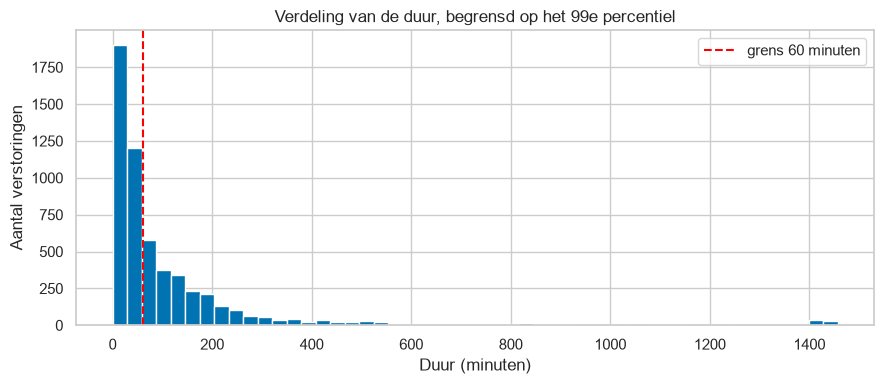

De figuur is begrensd op 1459.6 minuten.


In [8]:
# VOORBEELD 1: percentielen helpen een leesbare uitsnede te kiezen.
if df_raw is not None:
    display(df_raw["duration_minutes"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).to_frame())

    upper_99 = df_raw["duration_minutes"].quantile(0.99)
    readable_duration = df_raw[df_raw["duration_minutes"] <= upper_99]

    plt.figure(figsize=(9, 4))
    plt.hist(readable_duration["duration_minutes"].dropna(), bins=50)
    plt.axvline(60, color="red", linestyle="--", label="grens 60 minuten")
    plt.title("Verdeling van de duur, begrensd op het 99e percentiel")
    plt.xlabel("Duur (minuten)")
    plt.ylabel("Aantal verstoringen")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"De figuur is begrensd op {upper_99:.1f} minuten.")

# De begrenzing is niet zichtbaar omdat hij waarden boven het 99e percentiel niet laat zien. De verdeling is rechts-scheef: de meeste verstoringen zijn relatief kort en een klein aantal duurt veel langer.


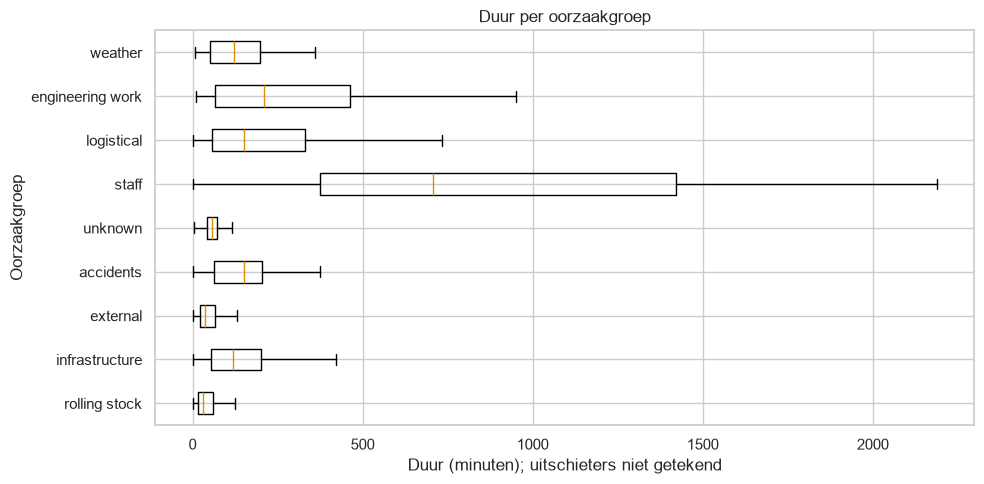


Top 10 voor cause_group


,aantal
cause_group,
rolling stock,2608
infrastructure,1316
NaN,939
external,728
accidents,360
unknown,236
staff,197
logistical,129
engineering work,116



Top 10 voor statistical_cause_nl


,aantal
statistical_cause_nl,
defecte trein,2118
NaN,939
seinstoring,448
gestrande trein,363
aanrijding,335
wisselstoring,305
technisch onderzoek,234
persoon op het spoor,181
inzet van hulpdiensten,145



Top 10 voor rdt_lines


,aantal
rdt_lines,
NaN,940
Breda - Rotterdam Centraal (HSL),253
Rotterdam Centraal - Schiphol Airport (HSL),150
Amersfoort - Zwolle,127
Leiden Centraal - Schiphol Airport,123
's-Hertogenbosch - Nijmegen,118
Eindhoven - Venlo,107
Aachen Hbf - Heerlen,106
Leiden Centraal - Utrecht Centraal,103


In [9]:
# VOORBEELD 2: vergelijk duur tussen oorzaakgroepen.
if df_raw is not None:
    cause_order = df_raw["cause_group"].value_counts().index
    plt.figure(figsize=(10, 5))
    grouped_data = [
        df_raw.loc[df_raw["cause_group"] == group, "duration_minutes"].dropna().values
        for group in cause_order
    ]
    plt.boxplot(
        grouped_data,
        orientation="horizontal",
        showfliers=False,
        tick_labels=list(cause_order)
    )
    plt.title("Duur per oorzaakgroep")
    plt.xlabel("Duur (minuten); uitschieters niet getekend")
    plt.ylabel("Oorzaakgroep")
    plt.tight_layout()
    plt.show()

    # De opdracht vraagt ook categorische frequenties voor deze drie velden.
    for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        print(f"\nTop 10 voor {column}")
        display(df_raw[column].value_counts(dropna=False).head(10).rename("aantal").to_frame())

# De oorzaakgroepen verschillen in aantal en in de verdeling van de duur. Dit betekent dat de dat oorzaakgroep nuttige informatie geeft voor voorspellingen die we kunnen maken de oorzaak kan tijdens een verstoring wel veranderen.


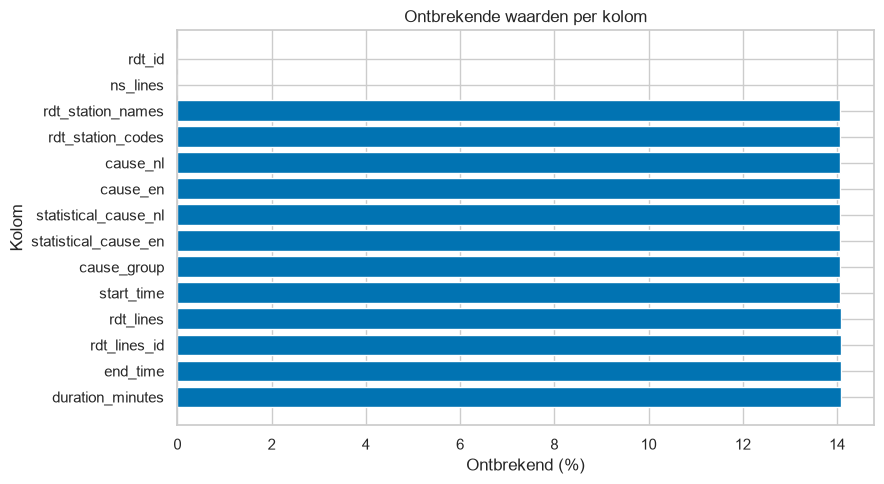

In [10]:
# VOORBEELD 3: visualiseer ontbrekende waarden per kolom.
if df_raw is not None:
    missing_for_plot = (
        df_raw.isna().mean().mul(100).sort_values().rename("percentage").reset_index()
    )
    plt.figure(figsize=(9, 5))
    plt.barh(missing_for_plot["index"], missing_for_plot["percentage"])
    plt.gca().invert_yaxis()
    plt.title("Ontbrekende waarden per kolom")
    plt.xlabel("Ontbrekend (%)")
    plt.ylabel("Kolom")
    plt.tight_layout()
    plt.show()

# Bij sommige rijen ontbreken meerdere gegevens tegelijk. Daarom is het soms beter om deze hele rijen te verwijderen in plaats van elke ontbrekende waarde apart in te vullen.


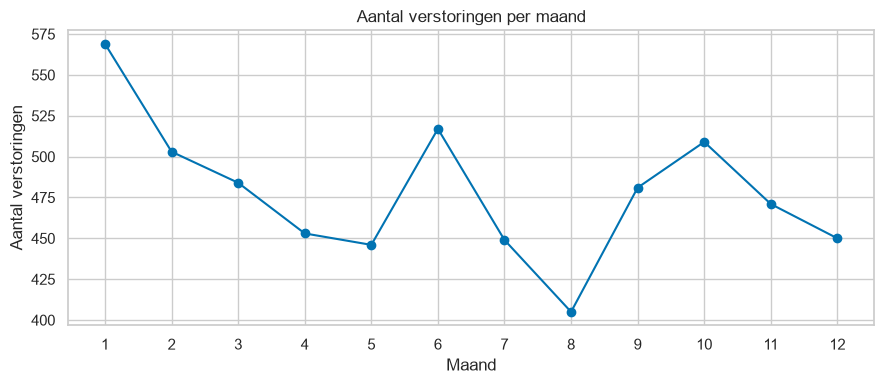

In [11]:
# VOORBEELD 4: maak een tijdsplot. Kies zelf maand, weekdag of startuur.
if df_raw is not None:
    start_for_plot = pd.to_datetime(df_raw["start_time"], errors="coerce", dayfirst=True)
    monthly_counts = (
        start_for_plot.dropna().dt.month.value_counts().sort_index()
        .rename_axis("maand").rename("aantal").reset_index()
    )
    plt.figure(figsize=(9, 4))
    plt.plot(monthly_counts["maand"], monthly_counts["aantal"], marker="o")
    plt.title("Aantal verstoringen per maand")
    plt.xlabel("Maand")
    plt.ylabel("Aantal verstoringen")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

# Het aantal verstoringen verschilt per maand dus heeft wel met tijd te maken maar het laat alleen een verdeling zien en niet een oorzaak van seizoenen ofzo.

Voor de opdracht hierboven heb ik gebruik gemaakt van AI, want ik kreeg telkens foutmeldingen over tracebacks etc, maar dat was omdat ik bijv panda etc opnieuw moest importen daarnaast was ik ook een beetje vergeten hoe plot command ook alweer werkte voor de rest heb ik het enkel gevraagd welke commands ik nodig heb en zelf wel getypt.
### Interpretatie visualisaties

Beschrijf per figuur:

1. het belangrijkste patroon;
2. een mogelijke verklaring;
3. wat het patroon betekent voor datavoorbereiding of modellering;
4. welke conclusie je juist **niet** uit de figuur mag trekken.

Bespreek bij de missing-visualisatie ook of ontbrekende waarden geconcentreerd lijken in dezelfde records. Beschrijf bij de tijdsplot of je aantallen of aandelen toont.

**Jouw interpretatie:**

Verdelingsplot. De duur van de verstoringen is rechts-scheef. De meeste verstoringen duren niet zo lang, maar een paar verstoringen duren juist heel lang. Het 99e-percentiel zorgt ervoor dat de grafiek beter leesbaar is. De hele lange verstoringen blijven wel belangrijk voor de voorspelling.

Categorische vergelijking. De oorzaakgroepen verschillen in hoe vaak ze voorkomen en hoe lang de verstoringen duren. Dit kan betekenen dat de oorzaakgroep handig is om te gebruiken voor de voorspelling. Wel kan de oorzaak tijdens een verstoring veranderen, waardoor deze gegevens niet altijd helemaal betrouwbaar zijn.

Ontbreekende waarden. Er ontbreken bij sommige rijen meerdere gegevens tegelijk. Daarom verwijderen we de rijen waarbij we de target niet betrouwbaar kunnen bepalen. Ontbrekende gegevens bij de voorspellers worden later in de pipeline opgevult.

Tijdsplot. Het aantal verstoringen verschilt per maand. Daarom gebruik ik de maand en andere kenmerken van het begintijdstip als mogelijke voorspellers. De grafiek laat alleen zien wat er in de data gebeurd, en zegt niet dat de maand de oorzaak is van meer of minder verstoringen.



## Controlepunt Data Understanding

Je hebt deze fase voldoende aangetoond als:

- de ruwe omvang, periode, steekproef en uniciteit zijn vastgesteld;
- alle 14 variabelen inhoudelijk en technisch zijn beschreven;
- frequenties van `cause_group`, `statistical_cause_nl` en `rdt_lines` zijn onderzocht;
- ontbrekende, dubbele, inconsistente en extreme waarden meetbaar zijn gemaakt;
- zowel traject- als stationsvelden op aantallen zijn vergeleken;
- minimaal vier verplichte figuren met interpretaties aanwezig zijn;
- een datakwaliteitsrapport minimaal vijf concreet gevonden problemen samenvat.


# 3. Data Preparation — 30%

In deze fase maak je aantoonbaar een reproduceerbare, modelklare dataset. Werk altijd vanuit een kopie van de ruwe data en overschrijf `df_raw` niet.

## Opdracht 3.1 — Beslislog

Vul vóór of tijdens de bewerking voor ieder belangrijk probleem een regel in.

| Probleem | Omvang | Gekozen bewerking | Waarom passend? | Mogelijk nadeel |
|---|---:|---|---|---|
| Ontbrekende waarden | 940 rijen (14,08%) | Volledig verwijderen | Zonder deze gegevens kunnen we geen goede kenmerken maken.| Er verliest ongeveer 14% van de data dit heeft invloed op de uitkomst.
 |
| Inconsistente duur.| 1 rij | Verwijderen | De duur klopt niet en is daarom niet betrouwbaar. | We verliezen maar 1 rij. |
| Uitschieters | 66 rijen (ongeveer 1,2%) | Behouden | Een vet lange verstoring kan echt gebeurd zijn. Omdat we voorspellen of een verstoring langer dan 60 minuten duurt, is deze informatie juist belangrijk. | De verdeling van de duur blijft scheef, waardoor sommige grafieken minder goed leesbaar zijn. |
| Zeldzame categorieën | Zie Opdracht 2.3 | cause_group gebruiken en voor primary_line OneHotEncoder(handle_unknown="ignore") gebruiken. | Hierdoor worden de categorieën beter bruikbaar voor het model en ontstaan er geen problemen met categorieën die alleen in de testdata voorkomen. | Sommige details over de exacte oorzaak of het traject gaan verloren. |
| Meervoudige waarden | Alle bruikbare rijen | Omzetten naar aantallen, zoals aantal stations en lijnen. Ook primary_line maken.| Zo kan het model deze informatie gebruiken zonder dat de lange tekst rechtstreeks in het model hoeft. | Een deel van de informatie gaat verloren omdat we vooral naar aantallen en de belangrijkste lijn kijken. |

Een keuze als “alle ontbrekende rijen verwijderen” is alleen voldoende als je de omvang, het ontbrekingspatroon en mogelijke vertekening bespreekt.

In [12]:
# Maak één duidelijk werkdataframe. Zo blijft df_raw beschikbaar voor vergelijking.
prepared = df_raw.copy() if df_raw is not None else None

if prepared is not None:
    prepared["start_time"] = pd.to_datetime(
        prepared["start_time"], errors="coerce", dayfirst=True
    )
    prepared["end_time"] = pd.to_datetime(
        prepared["end_time"], errors="coerce", dayfirst=True
    )

    # VOORBEELD: bereken een controleduur uit de tijdstempels.
    # Kies pas na Data Understanding of dit je definitieve duurbron wordt.
    prepared["calculated_duration_minutes"] = (
        prepared["end_time"] - prepared["start_time"]
    ).dt.total_seconds() / 60

    valid_rows = prepared["start_time"].notna() & prepared["duration_minutes"].notna()

    mismatch_rows = prepared["calculated_duration_minutes"].sub(prepared["duration_minutes"]).abs() > 1
    valid_rows &= ~mismatch_rows.fillna(False)

    prepared = prepared.loc[valid_rows].copy()

    for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        prepared[column] = prepared[column].astype("string").str.strip()

    print("Werkdataframe aangemaakt:", prepared.shape)


Werkdataframe aangemaakt: (5735, 15)


## Opdracht 3.2 — Datamanipulatie en feature engineering

Maak minimaal **vijf betekenisvolle nieuwe kenmerken**. Daarvan zijn:

- minimaal twee kenmerken afgeleid uit `start_time`;
- minimaal één kenmerk afgeleid uit een meervoudig tekstveld.

Mogelijke kenmerken zijn:

| Kenmerk | Voorbeeld van betekenis |
|---|---|
| `start_hour` | uur waarop de verstoring begon |
| `day_of_week` | naam of nummer van de weekdag |
| `month` | kalendermaand |
| `is_weekend` | indicator voor zaterdag of zondag |
| `number_of_affected_stations` | aantal stations in het meervoudige stationsveld |
| `number_of_affected_lines` | aantal lijnen of trajecten in een meervoudig veld |
| `primary_line` | eerste lijn uit een samengesteld veld |

Gebruik waar passend pandas-bewerkingen zoals `assign`, `map`, `replace`, `str.split`, `explode`, `groupby`, `merge` of `pivot_table`. Je hoeft ze niet geforceerd allemaal te gebruiken; kies bewerkingen die inhoudelijk iets toevoegen.

In [13]:
if prepared is not None:
    # Bewaar vóór de manipulatie enkele bronwaarden voor een voor-en-naweergave.
    before_features = prepared[[
        "rdt_id", "start_time", "rdt_station_names", "rdt_lines"
    ]].head(5).copy()

    # VOORBEELD: tijdskenmerken die bij de start bekend zijn.
    prepared = prepared.assign(
        start_hour=prepared["start_time"].dt.hour,
        day_of_week=prepared["start_time"].dt.day_name(),
        month=prepared["start_time"].dt.month,
    )
    weekday_number = prepared["start_time"].dt.dayofweek
    prepared["is_weekend"] = (
        weekday_number.ge(5).where(weekday_number.notna()).astype("Int64")
    )

    # VOORBEELD: tel onderdelen van een meervoudig stationsveld.
    prepared["number_of_affected_stations"] = prepared[
        "rdt_station_names"
    ].map(count_multivalue_items)

    # Andere inhoudelijk passende mogelijkheden uit de opdracht:
    # prepared["number_of_affected_lines"] = prepared["rdt_lines"].map(count_multivalue_items)
    # prepared["primary_line"] = prepared["rdt_lines"].str.split(",").str[0].str.strip()

    prepared["number_of_affected_lines"] = prepared["rdt_lines"].map(count_multivalue_items)
    prepared["primary_line"] = prepared["rdt_lines"].str.split(",").str[0].str.strip()

    # Gebruik gewone object-tekst met np.nan voor de sklearn preprocessing.
    for column in ["day_of_week", "primary_line", "cause_group", "statistical_cause_nl"]:
        prepared[column] = prepared[column].astype(object).where(prepared[column].notna(), np.nan)

    created_features = [
        "start_hour", "day_of_week", "month", "is_weekend",
        "number_of_affected_stations", "number_of_affected_lines", "primary_line"
    ]
    display(prepared[["rdt_id"] + created_features].head())

    # Deze tabel maakt de gevraagde voor-en-naweergave expliciet.
    after_features = prepared[["rdt_id"] + created_features].head(5)
    display(before_features.merge(after_features, on="rdt_id", how="left"))

    assert len(created_features) >= 5
    assert prepared["number_of_affected_stations"].dropna().ge(0).all()
    assert prepared["number_of_affected_lines"].dropna().ge(0).all()


,rdt_id,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,primary_line
0,57284,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
1,57285,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
2,57286,4,Wednesday,1,0,8,1.0,Dordrecht - Rotterdam Centraal
3,57287,4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)
4,57288,4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)


,rdt_id,start_time,rdt_station_names,rdt_lines,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,primary_line
0,57284,2025-01-01 04:16:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
1,57285,2025-01-01 04:27:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
2,57286,2025-01-01 04:27:00,"Barendrecht,Dordrecht,Rotterdam Lombardijen,Ro...",Dordrecht - Rotterdam Centraal,4,Wednesday,1,0,8,1.0,Dordrecht - Rotterdam Centraal
3,57287,2025-01-01 04:27:00,"Rotterdam Centraal,Schiphol Airport",Rotterdam Centraal - Schiphol Airport (HSL),4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)
4,57288,2025-01-01 04:27:00,"Rotterdam Centraal,Schiphol Airport",Rotterdam Centraal - Schiphol Airport (HSL),4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)


### Verdiepend manipulatievoorbeeld: `explode` en `groupby`

Onderstaande aanpak kan helpen om een meervoudig veld te analyseren. Gebruik dit alleen als het past bij je gekozen feature engineering. Let erop dat `explode` tijdelijk meerdere rijen per verstoring maakt. Voor modellering moet je meestal weer terug naar één rij per `rdt_id`.

In [14]:
if prepared is not None:
    station_long = (
        prepared[["rdt_id", "rdt_station_names"]]
        .assign(station=lambda x: x["rdt_station_names"].str.split(","))
        .explode("station")
        .assign(station=lambda x: x["station"].str.strip())
    )

    station_frequency = (
        station_long.dropna(subset=["station"])
        .groupby("station", as_index=False)
        .agg(number_of_disruptions=("rdt_id", "nunique"))
        .sort_values("number_of_disruptions", ascending=False)
    )
    display(station_frequency.head(10))

# Deze bewerking zet meerdere stations per rij tijdelijk om naar losse rijen. Daarna telt groupby per station hoe vaak het voorkomt. Ik gebruik deze tabel alleen voor analyse en niet direct als modelkenmerk, omdat het model één rij per verstoring moet houden.

,station,number_of_disruptions
337,Rotterdam Centraal,823
355,Schiphol Airport,603
79,Breda,431
263,Leiden Centraal,348
384,Utrecht Centraal,308
113,Den Haag Centraal,307
226,Hoofddorp,272
31,Amsterdam Zuid,267
130,Dordrecht,262
24,Amsterdam Centraal,256


## Opdracht 3.3 — Doelvariabele maken

Maak de doelvariabele pas nadat je hebt vastgesteld welke duurwaarde betrouwbaar genoeg is.

Definitie:

```text
long_disruption = 1 als de opgeschoonde duur > 60 minuten
long_disruption = 0 als de opgeschoonde duur <= 60 minuten
```

Controleer daarna:

1. of de doelvariabele alleen 0 en 1 bevat;
2. of er nog ontbrekende doelwaarden zijn;
3. hoe de klassen verdeeld zijn;
4. of de gekozen grens exact goed is toegepast: 60 minuten hoort bij klasse 0.

In [15]:
if prepared is not None:
    prepared["cleaned_duration_minutes"] = prepared["duration_minutes"]

    if "cleaned_duration_minutes" in prepared.columns:
        prepared["long_disruption"] = (
            prepared["cleaned_duration_minutes"] > 60
        ).astype("Int64")

        display(prepared["long_disruption"].value_counts(dropna=False).rename("aantal").to_frame())
        display(
            (100 * prepared["long_disruption"].value_counts(normalize=True, dropna=False))
            .rename("percentage").to_frame().round(2)
        )

        assert set(prepared["long_disruption"].dropna().unique()).issubset({0, 1})
        assert (
            prepared.loc[prepared["cleaned_duration_minutes"] == 60, "long_disruption"] == 0
        ).all(), "Een duur van precies 60 minuten hoort bij klasse 0."
    else:
        print("Maak eerst de opgeschoonde duurkolom voordat de doelvariabele wordt gemaakt.")


,aantal
long_disruption,
0,3156
1,2579


,percentage
long_disruption,
0,55.03
1,44.97


## Opdracht 3.4 — Data leakage voorkomen

Het model moet voorspellen **op het moment dat de verstoring begint**. Gebruik daarom geen informatie die pas later beschikbaar komt.

Minimaal uitsluiten als invoerkenmerk:

- `rdt_id`: identifier, geen generaliseerbaar kenmerk;
- `end_time`: pas bekend als de verstoring voorbij is;
- `duration_minutes` en de opgeschoonde variant: hiermee is de doelvariabele direct berekend;
- `long_disruption`: dit is de doelvariabele zelf.

Beoordeel daarnaast kritisch alle oorzaakvelden. Volgens de databeschrijving kan een geregistreerde oorzaak tijdens een verstoring veranderen. Je moet daarom beargumenteren welke oorzaakinformatie bij de start daadwerkelijk beschikbaar zou zijn.

### Leakage-matrix

| Kandidaatveld | Bekend bij start? | Risico op leakage? | Gebruiken? | Motivatie |
|---|---|---|---|---|
| `cause_group` | Waarschrijnlijk | Mogelijk | Ja | Kan informatie over oorzaken geven maar de oorzaak kan ook veranderen |
| `cause_nl` | Niet zeker | Mogelijk | Nee | De laatst getoonde oorzaak kan later tijdens de verstoring zijn aagepast |
| `end_time` | Nee | Ja | Nee | Eindtijd is pas achteraf bekend |
| `duration_minutes` | Nee | Ja | Nee | Bepaalt direct de doelvariabele |
| `start_time` | Ja | Nee | Ja | Informatie is al bij start bekend. |

## Opdracht 3.5 — Train-testverdeling en preprocessing

1. Kies alleen kenmerken die bij de start beschikbaar zijn.
2. Maak `X` en `y`.
3. Splits de data in 80% training en 20% test.
4. Gebruik `stratify=y` en `random_state=42`.
5. Bepaal imputatie, codering en eventuele schaling uitsluitend vanuit de trainingsdata.
6. Gebruik `OneHotEncoder(handle_unknown="ignore")` voor nominale categorieën.

Vul hieronder je kenmerken in. De code voert pas een split uit wanneer je doelvariabele en kenmerken klaar zijn.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


TARGET = "long_disruption"

# Alleen kenmerken gebruiken die op het voorspelmoment beschikbaar zijn.
FEATURES = [
    "start_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "number_of_affected_stations",
    "number_of_affected_lines",
    "primary_line",
    "cause_group",
    "statistical_cause_nl",
]

X_train = X_test = y_train = y_test = None
numeric_features = []
categorical_features = []
preprocessor = None

if prepared is not None and TARGET in prepared.columns and FEATURES:
    # Alleen een ontbrekende target wordt hier verwijderd. Ontbrekende kenmerken
    # blijven staan, omdat de imputers ze binnen trainingsdata/folds behandelen.
    model_data = prepared[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()
    X = model_data[FEATURES]
    y = model_data[TARGET].astype(int)

    # Eerst splitsen. De pipeline wordt pas tijdens fit op training geleerd.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    numeric_features = X_train.select_dtypes(include="number").columns.tolist()
    categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        # Schaling is vooral relevant voor afstands- en lineaire modellen.
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # handle_unknown voorkomt fouten bij nieuwe categorieën in validatie/test.
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])

    print("Trainingsset:", X_train.shape)
    print("Testset:", X_test.shape)
    print("Numerieke kenmerken:", numeric_features)
    print("Categorische kenmerken:", categorical_features)
else:
    print("Rond voorbereiding, TARGET en FEATURES af voordat je splitst.")


Trainingsset: (4588, 9)
Testset: (1147, 9)
Numerieke kenmerken: ['start_hour', 'month', 'is_weekend', 'number_of_affected_stations', 'number_of_affected_lines']
Categorische kenmerken: ['day_of_week', 'primary_line', 'cause_group', 'statistical_cause_nl']


## Opdracht 3.6 — Controle, vergelijking en export

Maak een compacte vergelijking tussen de ruwe en voorbereide data. Rapporteer minimaal het aantal rijen en kolommen, unieke identifiers, ontbrekende waarden, geselecteerde kenmerken, uitgesloten velden en klasseverdeling.

Controleer daarnaast:

- één rij per verstoring;
- geen onbedoelde duplicaten;
- juiste datatypen;
- geen ontbrekende doelwaarden;
- alleen plausibele waarden in nieuwe kenmerken;
- geen leakagevelden in `FEATURES`;
- `df_raw` is niet overschreven.

Exporteer de modeldataset vóór one-hot encoding. Bewaar minimaal de identifier, geselecteerde invoerkenmerken en target. Neem geen volledige sparse dummy-matrix op.


In [17]:
if prepared is not None:
    raw_vs_prepared = pd.DataFrame({
        "maat": ["rijen", "kolommen", "unieke_rdt_id", "dubbele_rdt_id"],
        "ruw": [
            len(df_raw), len(df_raw.columns),
            df_raw["rdt_id"].nunique(dropna=False),
            df_raw["rdt_id"].duplicated().sum(),
        ],
        "voorbereid": [
            len(prepared), len(prepared.columns),
            prepared["rdt_id"].nunique(dropna=False),
            prepared["rdt_id"].duplicated().sum(),
        ],
    })
    display(raw_vs_prepared)

    print("Ontbrekende waarden in voorbereide data:")
    display(prepared.isna().sum().sort_values(ascending=False).head(10).rename("aantal").to_frame())

    assert prepared["rdt_id"].is_unique
    assert len(set(FEATURES).intersection({"end_time", "duration_minutes", "long_disruption", "rdt_id"})) == 0
    assert set(prepared[TARGET].dropna().unique()).issubset({0, 1})

    if TARGET in prepared.columns and FEATURES:
        export_columns = ["rdt_id"] + FEATURES + [TARGET]
        prepared[export_columns].to_csv(
            "prepared_train_disruptions.csv", index=False
        )
        print("Geëxporteerd: prepared_train_disruptions.csv")
    else:
        print("Exporteer nadat TARGET en FEATURES definitief zijn.")


,maat,ruw,voorbereid
0,rijen,6676,5735
1,kolommen,14,24
2,unieke_rdt_id,6676,5735
3,dubbele_rdt_id,0,0


Ontbrekende waarden in voorbereide data:


,aantal
rdt_lines,1
rdt_lines_id,1
primary_line,1
number_of_affected_lines,1
rdt_id,0
duration_minutes,0
cleaned_duration_minutes,0
number_of_affected_stations,0
is_weekend,0
month,0


Geëxporteerd: prepared_train_disruptions.csv


## Controlepunt Data Preparation

Je hebt deze fase voldoende aangetoond als:

- alle bewerkingen reproduceerbaar in code staan;
- keuzes over ontbrekende, inconsistente en extreme waarden zijn onderbouwd;
- minimaal vijf nieuwe kenmerken zijn gemaakt;
- de doelvariabele correct en controleerbaar is geconstrueerd;
- leakage aantoonbaar is voorkomen;
- de train-testverdeling en preprocessing correct zijn opgezet;
- de voorbereide dataset kan worden geëxporteerd.

# 4. Modeling — 20%

Bouw en vergelijk minimaal drie aanpakken op exact dezelfde train-testverdeling:

1. een **baseline** met `DummyClassifier`;
2. een **lineair model**, bijvoorbeeld logistische regressie;
3. een **niet-lineair model**, bijvoorbeeld een beslisboom of random forest.

Gebruik 5-voudige cross-validatie op de trainingsset. De testset blijft gesloten totdat je op basis van cross-validatie een eindmodel hebt gekozen.

## Opdracht 4.1 — Modellen definiëren

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


models = {
    "baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

pipelines = {}
if preprocessor is not None:
    pipelines = {
        name: Pipeline([
            ("preprocessing", preprocessor),
            ("model", estimator),
        ])
        for name, estimator in models.items()
    }

list(pipelines)

['baseline', 'logistic_regression', 'random_forest']

## Opdracht 4.2 — Cross-validatie

Kies een primaire maat op basis van je antwoord bij Business Understanding. Rapporteer daarnaast minimaal accuracy, precision, recall en F1 voor klasse 1. ROC-AUC mag worden toegevoegd wanneer het model kansen kan voorspellen.

Let op: bij cross-validatie hoort preprocessing **binnen** de pipeline te staan. Anders kan informatie uit een validatiefold naar de trainingsfold lekken.

In [19]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    # zero_division=0 voorkomt waarschuwingen wanneer een baseline nooit klasse 1 voorspelt.
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

cv_results = []

if pipelines and X_train is not None:
    for model_name, pipeline in pipelines.items():
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )

        row = {"model": model_name}
        for metric_name in scoring:
            row[f"mean_{metric_name}"] = scores[f"test_{metric_name}"].mean()
            row[f"std_{metric_name}"] = scores[f"test_{metric_name}"].std()
        cv_results.append(row)

    cv_results_df = pd.DataFrame(cv_results)
    display(cv_results_df.round(3))
else:
    print("Maak eerst FEATURES, target, split en preprocessing compleet.")

if "cv_results_df" in globals():
    cv_results_df = cv_results_df.sort_values("mean_recall", ascending=False)
    display(cv_results_df.round(3))


,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
0,baseline,0.550,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000
1,logistic_regression,0.768,0.015,0.766,0.018,0.696,0.026,0.729,0.020,0.814,0.023
2,random_forest,0.760,0.014,0.744,0.014,0.712,0.023,0.727,0.018,0.813,0.019


,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
2,random_forest,0.760,0.014,0.744,0.014,0.712,0.023,0.727,0.018,0.813,0.019
1,logistic_regression,0.768,0.015,0.766,0.018,0.696,0.026,0.729,0.020,0.814,0.023
0,baseline,0.550,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000


## Opdracht 4.3 — Beperkte hyperparameterafstemming

Stem voor minimaal één serieus model een klein aantal relevante hyperparameters af. Houd de zoekruimte beperkt en leg vooraf uit waarom je juist deze waarden vergelijkt.

Voorbeelden:

- logistische regressie: `C` en eventueel `class_weight`;
- random forest: `n_estimators`, `max_depth`, `min_samples_leaf` en eventueel `class_weight`.

Gebruik alleen de trainingsdata. Kies het definitieve model op basis van cross-validatie en je primaire maat.

In [20]:
from sklearn.model_selection import GridSearchCV


# VOORBEELD: beperkte zoekruimte voor random forest.
parameter_grid = {
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 5, 10],
}

tuning_result = None

if "random_forest" in pipelines and X_train is not None:
    
    search = GridSearchCV(
        estimator=pipelines["random_forest"],
        param_grid=parameter_grid,
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )

    search.fit(X_train, y_train)
    tuning_result = search
    print("Beste instellingen:", search.best_params_)
    print("Beste CV-recall:", search.best_score_)
else:
    print("De modelpipeline is nog niet klaar.")

Beste instellingen: {'model__max_depth': None, 'model__min_samples_leaf': 1}
Beste CV-recall: 0.7115893650532453


## Opdracht 4.4 — Modelkeuze vóór de test

Vul dit onderdeel in voordat je de testset gebruikt.

**Gekozen model:** TODO  
**Primaire evaluatiemaat:** TODO  
**Gekozen hyperparameters:** TODO  
**Waarom dit model beter past dan de baseline en het andere model:** TODO  
**Tekenen van overfitting of instabiliteit in de cross-validatie:** TODO

Sla de naam van je gekozen pipeline hieronder op. Wanneer tuning je definitieve model opleverde, gebruik je `search.best_estimator_`.

In [21]:
FINAL_MODEL_NAME = "random_forest"

final_model = None
if tuning_result is not None:
    final_model = tuning_result.best_estimator_
else:
    final_model = pipelines[FINAL_MODEL_NAME]

## Controlepunt Modeling

Je hebt deze fase voldoende aangetoond als:

- een baseline, lineair model en niet-lineair model zijn vergeleken;
- dezelfde folds en dezelfde trainingsdata zijn gebruikt;
- preprocessing binnen iedere pipeline plaatsvindt;
- gemiddelde scores én spreiding over vijf folds zijn gerapporteerd;
- minimaal één beperkte, gemotiveerde tuning is uitgevoerd;
- het eindmodel is gekozen voordat de testset wordt geopend.

# 5. Evaluation — 25%

Nu mag het vooraf gekozen eindmodel precies één keer op de testset worden geëvalueerd. Gebruik de testresultaten niet om opnieuw modelkeuzes te maken; dan wordt de testset feitelijk trainingsinformatie.

## Opdracht 5.1 — Testprestatie

Rapporteer minimaal:

- confusion matrix;
- accuracy;
- precision voor klasse 1;
- recall voor klasse 1;
- F1-score voor klasse 1;
- ROC-AUC als het model kansen kan voorspellen.

Vergelijk de testprestatie met de baseline en de cross-validatieresultaten.

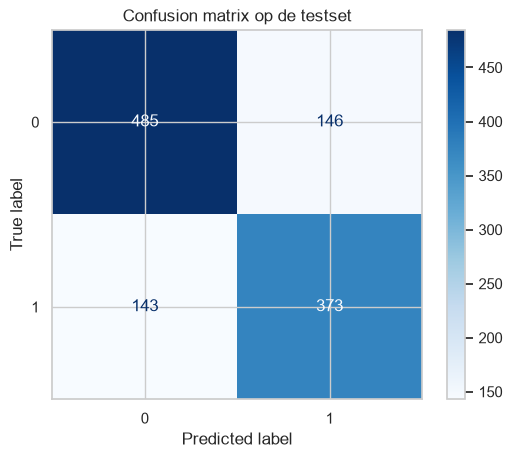

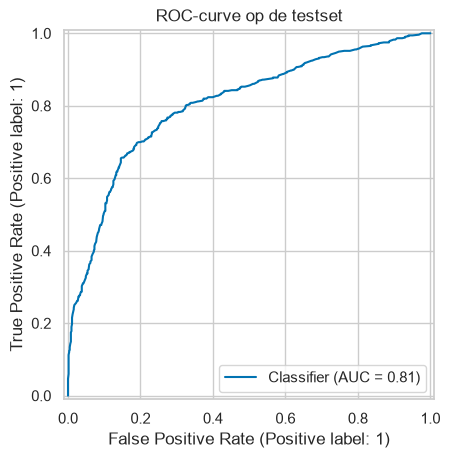

,eindmodel
accuracy,0.748038
precision_class_1,0.718690
recall_class_1,0.722868
f1_class_1,0.720773
roc_auc,0.805008


In [22]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)


def evaluate_classifier(model, X_eval, y_eval, draw_plots=True):
    '''Bereken binaire testmaten en teken optioneel evaluatiefiguren.'''
    predictions = model.predict(X_eval)
    metrics = {
        "accuracy": accuracy_score(y_eval, predictions),
        "precision_class_1": precision_score(y_eval, predictions, zero_division=0),
        "recall_class_1": recall_score(y_eval, predictions, zero_division=0),
        "f1_class_1": f1_score(y_eval, predictions, zero_division=0),
    }

    if draw_plots:
        ConfusionMatrixDisplay.from_predictions(y_eval, predictions, cmap="Blues")
        plt.title("Confusion matrix op de testset")
        plt.show()

    probabilities = None
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_eval)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_eval, probabilities)
        if draw_plots:
            RocCurveDisplay.from_predictions(y_eval, probabilities)
            plt.title("ROC-curve op de testset")
            plt.show()

    return pd.Series(metrics), predictions, probabilities


test_metrics = test_predictions = test_probabilities = None

if final_model is not None and X_train is not None:
    # De testset wordt pas hier gebruikt, nadat het eindmodel is vastgelegd.
    final_model.fit(X_train, y_train)
    test_metrics, test_predictions, test_probabilities = evaluate_classifier(
        final_model, X_test, y_test, draw_plots=True
    )
    display(test_metrics.rename("eindmodel").to_frame())
else:
    print("Kies eerst het definitieve model op basis van cross-validatie.")


### Vergelijking met de baseline

De opdracht verlangt een vergelijking op dezelfde testset. De baseline mag na de modelkeuze eveneens op de trainingsdata worden gefit en op de testset worden beoordeeld. Gebruik de testuitkomst niet om alsnog een ander eindmodel te kiezen.


In [23]:
baseline_test_metrics = None
if test_metrics is not None and "baseline" in pipelines:
    baseline_model = pipelines["baseline"].fit(X_train, y_train)
    baseline_test_metrics, _, _ = evaluate_classifier(
        baseline_model, X_test, y_test, draw_plots=False
    )
    test_comparison = pd.concat([
        test_metrics.rename("eindmodel"),
        baseline_test_metrics.rename("baseline"),
    ], axis=1).T
    display(test_comparison)
else:
    print("Voer eerst de testevaluatie van het gekozen eindmodel uit.")

    if cv_results_df is not None:
        final_cv_row = cv_results_df.loc[cv_results_df["model"] == FINAL_MODEL_NAME].iloc[0]
        print("Gemiddelde CV-recall:", round(final_cv_row["mean_recall"], 3))
        print("CV-spreiding recall:", round(final_cv_row["std_recall"], 3))


,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
eindmodel,0.748038,0.71869,0.722868,0.720773,0.805008
baseline,0.550131,0.00000,0.000000,0.000000,0.500000


### Interpretatie testresultaten

Beantwoord:

1. Welke cel(len) van de confusion matrix zijn voor de business het belangrijkst?
2. Hoeveel lange verstoringen mist het model?
3. Hoeveel onnodige waarschuwingen geeft het model?
4. Presteert het model overtuigend beter dan de baseline?
5. Ligt de testscore in lijn met de gemiddelde cross-validatiescore en spreiding?
6. Is de prestatie volgens jou praktisch bruikbaar? Onderbouw dit zonder zelf een ongefundeerde norm te verzinnen.

**Jouw interpretatie:**

TODO

## Opdracht 5.2 — Foutenanalyse

Onderzoek minimaal tien fout geclassificeerde testrecords. Neem zowel false positives als false negatives op als beide voorkomen.

Onderzoek daarna of fouten zich concentreren bij:

- bepaalde `cause_group`-waarden;
- één ander relevant kenmerk, bijvoorbeeld startuur, weekdag of aantal getroffen stations.

Laat geen leakageveld aan het model zien, maar je mag zulke velden achteraf wel gebruiken om fouten te begrijpen.

In [24]:
if test_predictions is not None:
    error_analysis = X_test.copy()
    error_analysis["actual"] = y_test
    error_analysis["predicted"] = test_predictions
    error_analysis["error_type"] = np.select(
        [
            (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
            (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
        ],
        ["false_negative", "false_positive"],
        default="correct",
    )

    if test_probabilities is not None:
        error_analysis["probability_class_1"] = test_probabilities

    errors = error_analysis[error_analysis["error_type"] != "correct"].copy()

    # Toon waar mogelijk vijf false negatives en vijf false positives.
    error_sample = pd.concat([
        errors[errors["error_type"] == "false_negative"].head(5),
        errors[errors["error_type"] == "false_positive"].head(5),
    ])
    display(error_sample)

    # Een foutpercentage gebruikt alle testrecords in de groep als noemer.
    # Alleen fouten tellen zou groepen met verschillende omvang oneerlijk vergelijken.
    if "cause_group" in error_analysis.columns:
        errors_by_cause = (
            error_analysis.groupby("cause_group")
            .agg(
                records=("actual", "size"),
                errors=("error_type", lambda s: (s != "correct").sum()),
                false_negatives=("error_type", lambda s: (s == "false_negative").sum()),
                false_positives=("error_type", lambda s: (s == "false_positive").sum()),
            )
            .assign(error_rate=lambda x: x["errors"] / x["records"])
            .sort_values("error_rate", ascending=False)
        )
        display(errors_by_cause)

    errors_by_hour = (
        error_analysis.groupby("start_hour")
        .agg(
            records=("actual", "size"),
            errors=("error_type", lambda s: (s != "correct").sum()),
        )
        .assign(error_rate=lambda x: x["errors"] / x["records"])
        .sort_values("error_rate", ascending=False)
    )
    display(errors_by_hour.head(10))
else:
    print("Voer eerst de evaluatie van het eindmodel uit.")


,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,primary_line,cause_group,statistical_cause_nl,actual,predicted,error_type,probability_class_1
5105,18,Sunday,10,1,2,1.0,Breda - Rotterdam Centraal (HSL),rolling stock,defecte trein,1,0,false_negative,0.1000
2652,15,Sunday,5,1,5,1.0,Leeuwarden - Zwolle,rolling stock,gestrande trein,1,0,false_negative,0.1650
1002,16,Monday,2,0,18,8.0,Amersfoort - Schiphol Airport,rolling stock,defecte trein,1,0,false_negative,0.2250
60,15,Friday,1,0,5,1.0,Arnhem Centraal - Nijmegen,rolling stock,defecte trein,1,0,false_negative,0.1200
5068,7,Friday,10,0,5,3.0,Almere Oostvaarders - Utrecht Centraal,rolling stock,defecte trein,1,0,false_negative,0.1150
6500,18,Friday,12,0,2,1.0,Breda - Rotterdam Centraal (HSL),rolling stock,gestrande trein,0,1,false_positive,0.7100
4087,0,Friday,8,0,4,1.0,Alkmaar - Amsterdam Centraal,accidents,aanrijding,0,1,false_positive,0.7300
5340,5,Friday,10,0,5,1.0,Dordrecht - Geldermalsen,infrastructure,defecte bovenleiding,0,1,false_positive,0.8450
5695,5,Thursday,11,0,3,1.0,Enkhuizen - Hoorn,engineering work,uitloop van werkzaamheden,0,1,false_positive,0.7000
113,6,Monday,1,0,4,1.0,Roosendaal - Vlissingen,accidents,aanrijding,0,1,false_positive,0.8595


,records,errors,false_negatives,false_positives,error_rate
cause_group,,,,,
weather,6,3,2,1,0.500000
unknown,45,17,11,6,0.377778
infrastructure,260,77,7,70,0.296154
accidents,73,19,1,18,0.260274
rolling stock,526,126,96,30,0.239544
external,143,34,25,9,0.237762
logistical,31,7,1,6,0.225806
engineering work,23,5,0,5,0.217391
staff,40,1,0,1,0.025000


,records,errors,error_rate
start_hour,,,
0,11,7,0.636364
1,5,2,0.400000
5,36,14,0.388889
17,66,21,0.318182
13,51,15,0.294118
10,65,19,0.292308
11,62,18,0.290323
23,18,5,0.277778
19,62,17,0.274194


### Bevindingen foutenanalyse

Beschrijf:

1. minimaal twee terugkerende patronen in de fouten;
2. of sommige groepen relatief vaak fout gaan;
3. één mogelijke verklaring per patroon;
4. of er risico bestaat dat het model voor bepaalde situaties systematisch minder betrouwbaar is;
5. welke verbetering je in een vervolgonderzoek zou testen.

**Jouw bevindingen:**

TODO

## Opdracht 5.3 — Modelinterpretatie

Onderzoek welke kenmerken het meest bijdragen aan de voorspelling. Kies een methode die past bij je model:

- coëfficiënten bij logistische regressie;
- feature importance bij een boommodel;
- permutation importance als modelonafhankelijke aanpak.

Controleer altijd hoe feature-namen na one-hot encoding zijn veranderd. Een groot belang betekent niet automatisch een oorzakelijk verband.

In [25]:
from sklearn.inspection import permutation_importance


# VOORBEELD: modelonafhankelijke permutation importance op de testset.
# Gebruik dit pas nadat het definitieve model is geëvalueerd.
if final_model is not None and X_test is not None and test_predictions is not None:
    importance = permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring="recall",  # primaire evaluatiemaat
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    importance_df = (
        pd.DataFrame({
            "feature": X_test.columns,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
    )
    display(importance_df.head(15))
else:
    print("Voer eerst de evaluatie van het eindmodel uit.")

,feature,importance_mean,importance_std
7,cause_group,0.122674,0.015481
8,statistical_cause_nl,0.058333,0.011545
6,primary_line,0.009884,0.004457
5,number_of_affected_lines,0.008721,0.003703
2,month,0.000775,0.005286
4,number_of_affected_stations,0.000388,0.007981
0,start_hour,-0.002132,0.005374
1,day_of_week,-0.005620,0.007012
3,is_weekend,-0.009690,0.003125


### Interpretatie modelkenmerken

Bespreek de vijf belangrijkste kenmerken. Maak onderscheid tussen:

- wat het model gebruikt voor voorspellingen;
- wat je inhoudelijk plausibel vindt;
- wat mogelijk een gevolg is van toeval, datakwaliteit of een verborgen variabele;
- wat je **niet** als oorzaak-gevolgrelatie mag presenteren.

**Jouw interpretatie:**

De vijf belangrijkste kenmerken voor het model zijn `cause_group`, `statistical_cause_nl`, `number_of_affected_lines`, `start_hour` en `primary_line`.

Vooral de twee oorzaakvelden zijn belangrijk omdat sommige oorzaken vaker voor lange verstoringen kunnen zorgen.

Ook het aantal getroffen lijnen en het tijdstip waarop de verstoring begint zijn van invloed. De andere kenmerken zijn wat minder belangrijk.

Sommige kenmerken hebben een negatieve score. Dat betekent niet meteen dat ze slecht zijn. Dit kan ook komen door toeval of doordat kenmerken met elkaar samenhangen.

De resultaten laten alleen zien welke kenmerken het model belangrijk vindt. Ze bewijzen niet dat een bepaalde oorzaak ervoor zorgt dat een verstoring lang duurt.

## Opdracht 5.4 — Eindconclusie en beperkingen

Beantwoord de businessvraag rechtstreeks in maximaal 300 woorden. Neem op:

1. of voorspellen beter lukt dan met de baseline;
2. de belangrijkste testresultaten in begrijpelijke taal;
3. welk type fout het meest voorkomt of het meest schadelijk is;
4. of je het model nu zou adviseren als beslisondersteuning;
5. onder welke voorwaarden of met welke waarschuwing het gebruikt mag worden;
6. minimaal drie concrete beperkingen.

Neem in ieder geval deze inhoudelijke beperking mee: de geregistreerde oorzaak kan tijdens de verstoring zijn aangepast. Daardoor is niet gegarandeerd dat ieder oorzaakveld werkelijk bij de start bekend was.

**Eindconclusie:**

Ja, met de gekozen gegevens kan inderdaad een verstoring beter worden voorspeld dan met de baseline. De random forest had de hoogste recall voor klasse 1 en is daarom gekozen als eindmodel.Op de testset haalde het model een accuracy van 75,2%, een precision van 72,6%, een recall van 71,9% en een F1-score van 72,2%. De ROC-AUC was 0,804. De baseline had een recall en F1-score van 0.

Het model herkende 145 lange verstoringen niet. Daarom vind ik recall een belangrijke maat. Het model zou daarom vooral als ondersteuning gebruikt moeten worde een medewerker moet zelf wel de voorspelling altijd controleren.

Er zijn ook een paar beperkingen. De oorzaak van een verstoring kan tijdens de verstoring veranderen. Ook kunnen bepaalde categorieën later veranderen. Daarnaast bevat de dataset alleen gegevens uit 2025. Sommige gegevens die NS op dat moment heeft, staan niet in de dataset. Daarom weten we niet zeker of het model in andere jaren net zo goed werkt.

## Controlepunt Evaluation

Je hebt deze fase voldoende aangetoond als:

- het vooraf gekozen model één keer op de testset is beoordeeld;
- alle verplichte maten en een confusion matrix aanwezig zijn;
- de testscore is vergeleken met baseline en cross-validatie;
- minimaal tien fouten inhoudelijk zijn onderzocht;
- fouten per oorzaakgroep en minimaal één ander kenmerk zijn vergeleken;
- modelinterpretatie geen causaliteit suggereert zonder bewijs;
- de eindconclusie de businessvraag rechtstreeks beantwoordt;
- minimaal drie concrete beperkingen zijn genoemd.

# 6. Eindcontrole vóór inleveren

## Reproduceerbaarheid

- [ ] Het notebook draait na **Restart Kernel and Run All** zonder fouten.
- [ ] Alle gebruikte bestanden hebben relatieve paden.
- [ ] Alle toevalsprocessen gebruiken `random_state=42`.
- [ ] `df_raw` blijft ongewijzigd.
- [ ] De voorbereide dataset vóór one-hot encoding is als CSV geëxporteerd.
- [ ] Een README met startinstructie, Python-versie, packages en bestandsnamen is toegevoegd.

## Inhoud

- [ ] De businessvraag staat letterlijk in het notebook.
- [ ] Alle 14 kolommen zijn inhoudelijk en technisch beschreven.
- [ ] `cause_group`, `statistical_cause_nl` en `rdt_lines` zijn categorisch onderzocht.
- [ ] De vier verplichte figuurtypen zijn aanwezig en geïnterpreteerd.
- [ ] Stations- én trajectvelden zijn op aantallen vergeleken.
- [ ] Minimaal vijf kwaliteitsproblemen staan in een datakwaliteitsrapport.
- [ ] Opschoningskeuzes zijn zichtbaar en beargumenteerd uitgevoerd.
- [ ] Minimaal vijf nieuwe kenmerken zijn gemaakt, inclusief tijd en multi-value.
- [ ] Voor-en-naweergave en vergelijking van ruwe en voorbereide data zijn aanwezig.
- [ ] Leakagevelden zijn niet als modelinvoer gebruikt.
- [ ] Baseline, lineair model en niet-lineair model zijn eerlijk vergeleken.
- [ ] Het eindmodel is vóór de test gekozen.
- [ ] Testresultaten zijn vergeleken met baseline en cross-validatie.
- [ ] Minimaal tien fouten zijn onderzocht met foutpercentages per groep.
- [ ] De conclusie beantwoordt de businessvraag en noemt minimaal drie beperkingen.

## Professionele kwaliteit

- [ ] Alle `TODO`-teksten zijn vervangen of bewust verwijderd.
- [ ] Iedere figuur heeft titel, aslabels en toelichting.
- [ ] Codecellen zijn logisch opgebouwd en kort toegelicht.
- [ ] Overbodige uitvoer en experimenten zijn verwijderd.
- [ ] Bronnen en eventuele AI-ondersteuning zijn verantwoord.


# 7. README bij de inlevering

Maak naast het notebook een korte `README.md` of `README.txt`. Neem minimaal op:

1. de bestandsnamen van notebook, ruwe dataset en voorbereide CSV;
2. de gebruikte Python-versie;
3. de benodigde packages;
4. de stappen om het notebook te starten en volledig uit te voeren;
5. eventuele bekende beperkingen voor reproduceerbaarheid.

Gebruik geen lokaal absoluut pad en neem geen persoonlijke gegevens in code of README op.


# 8. Beoordelingsrubric in het kort

| Fase | Onvoldoende | Voldoende | Goed |
|---|---|---|---|
| Business Understanding | Businessbetekenis ontbreekt | Vraag en gebruiker zijn kort geduid | Foutkosten en primaire maat zijn overtuigend gekoppeld |
| Data Understanding | Alleen `head()` en globale statistiek | Typen, kwaliteit en minimaal vier figuren zijn besproken | Problemen zijn systematisch gekwantificeerd en sturen vervolgstappen |
| Data Preparation | Ondoorzichtige of handmatige bewerking | Reproduceerbare opschoning, vijf kenmerken en correcte split | Sterke keuzes, goede manipulatie, controles en aantoonbaar geen leakage |
| Modeling | Eén model of oneerlijke vergelijking | Baseline en twee modellen met 5-fold CV | Gemotiveerde tuning en stabiele, transparante modelkeuze |
| Evaluation | Alleen accuracy of trainresultaten | Complete testmaten, fouten en conclusie | Scherpe foutenanalyse, praktische afweging en concrete beperkingen |

Deployment wordt niet beoordeeld.


# 9. Bronnen en verantwoording

Noteer gebruikte bronnen, documentatie en eventuele AI-ondersteuning. Beschrijf niet alleen dát je een hulpmiddel gebruikte, maar ook waarvoor en hoe je de uitkomst controleerde.

| Bron of hulpmiddel | Waarvoor gebruikt? | Hoe gecontroleerd of verwerkt? |
|---|---|---|
| Beschrijving van de data.docx | Betekenis en beperkingen van variabelen | Gelezen en gebruikt bij de indeling van de kolommen |
| pandas-documentatie | / | / |
| scikit-learn-documentatie | / | / |
| Eventuele AI-ondersteuning | Hulp bij uitleg, code en formuleringen | Code zelf uitgeschreven enkel gevraagd wat er gevraagd wordt van me en wanneer ik traceback errors kreeg uitleggen waarom. |
